In [ ]:
import pandas as pd
data=pd.read_csv("C:\\Users\\Laptop links\\Desktop\\ML\\Lab2\\Admission_Predict.csv")
print(data.head())


   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


In [ ]:
data.drop("Serial No.",axis=1, inplace=True)
y=data["Chance of Admit "]
data.drop("Chance of Admit ",axis=1,inplace=True)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train,X_test,Y_train,Y_test=train_test_split(data,y,test_size=0.2)
lr=LinearRegression()
lr.fit(X_train,Y_train)


LinearRegression()

In [ ]:
pred=lr.predict(X_test)
print(pred)

[0.69684319 0.62532181 0.93586103 0.5906211  0.50757775 0.68880122
 0.5172037  0.67235571 0.6978786  0.62339294 0.73333835 0.59596539
 0.60197913 0.90150829 0.84667244 0.66049993 0.71742301 0.59573996
 0.44068245 0.83614511 0.71898652 0.93794955 0.85325751 0.70678148
 0.78678967 0.89726913 0.66003761 0.53396891 0.47004536 0.95079739
 0.80813857 0.62593519 0.819627   0.75598169 0.9247511  0.79692036
 0.67894492 0.78272403 0.59433576 0.83164181 0.48502826 0.55120618
 0.90976246 0.81117545 0.58219056 0.84817129 0.73578843 0.60730191
 0.81734493 0.9903068  0.54176106 0.79617212 0.88701923 0.8223338
 0.61635246 0.73572036 0.59628826 0.79260735 0.76762664 0.65138461
 0.50344594 0.74248349 0.60625901 0.56247144 0.65113854 0.73524205
 0.66304056 0.70371655 0.64385982 0.43310097 0.63770136 0.6401414
 0.6201696  0.58053411 0.67820125 0.96846757 0.67388941 0.57670499
 0.82099341 0.6052947  0.69042633 0.64343313 0.86020727 0.88268868
 0.72571125 0.61991354 0.59451612 0.58512039 0.54976894 0.746572

In [ ]:
print(Y_test.shape)
print(pred.shape)


(100,)
(400,)


In [ ]:
import numpy as np
from sklearn import metrics
rmse=np.sqrt(metrics.mean_squared_error(Y_test,pred))
print(rmse)

0.07325598138946769


In [ ]:
import pandas as pd
dataset=pd.read_csv("headbrain.csv")
print(dataset)

     Gender  Age Range  Head Size(cm^3)  Brain Weight(grams)
0         1          1             4512                 1530
1         1          1             3738                 1297
2         1          1             4261                 1335
3         1          1             3777                 1282
4         1          1             4177                 1590
..      ...        ...              ...                  ...
232       2          2             3214                 1110
233       2          2             3394                 1215
234       2          2             3233                 1104
235       2          2             3352                 1170
236       2          2             3391                 1120

[237 rows x 4 columns]


In [ ]:
X=dataset["Head Size(cm^3)"].values
y=dataset["Brain Weight(grams)"].values

In [ ]:
import numpy as np
X_sum=np.sum(X)
X_squared_sum=np.sum(X*X)
n=len(X)
print("Sum of X:",X_sum)
print("Sum of squared X:",X_squared_sum)
print("length is:",n)

Sum of X: 861256
Sum of squared X: 3161283190
length is: 237


In [ ]:
numer=(n*np.sum(X*y))-((np.sum(X))*(np.sum(y)))
demon=(n*X_squared_sum)-X_sum**2
w1=numer/demon
print("w1 is:",w1)


w1 is: 0.2634293394893993


In [ ]:
w0=(np.sum(y)-(w1*(X_sum)))/n
print("w0 is:",w0)

w0 is: 325.57342104944274


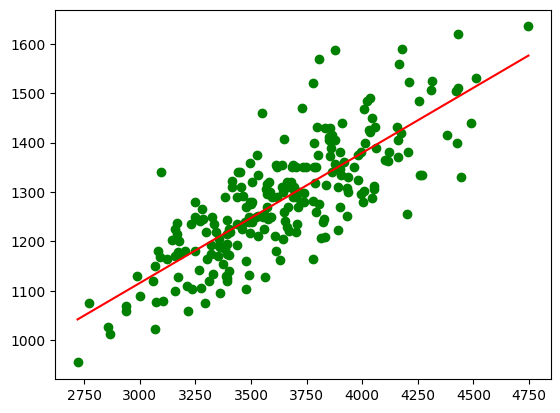

In [ ]:
import matplotlib.pyplot as plt
max_x=np.max(X)
min_x=np.min(X)
x1=np.linspace(max_x,min_x)
y1=w0+w1*x1
plt.plot(x1,y1,color="red")
plt.scatter(X,y,color="green")
plt.show()


In [ ]:
rmse=0
for i in range(n):
    y_pred=w0+w1*X[i]
    rmse=rmse+(y_pred-y[i])**2
rmse=np.sqrt(rmse/n)
print("RMSE:",rmse)

RMSE: 72.12062137837088


In [ ]:

res=0
tot=0
for i in range(n):
    y_pred=w0+w1*X[i]
    res+=(y[i]-y_pred)**2
    tot+=(y[i]-np.mean(y))**2
r2=1-(res/tot)
print("R2 is:",r2)




R2 is: 0.6393117199570004


In [ ]:
import pandas as pd
data1=pd.read_csv("Medical Cost Personal Datasets.csv")
print(data1.head(5))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
print(data1.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
le=LabelEncoder()
oe=OneHotEncoder()
data1["smoker"]=le.fit_transform(data1["smoker"])
data1["region"]=le.fit_transform(data1["region"])
data1["sex"]=le.fit_transform(data1["sex"])

In [ ]:
print(data1)


      age  sex     bmi  children  smoker  region      charges
0      19    0  27.900         0       1       3  16884.92400
1      18    1  33.770         1       0       2   1725.55230
2      28    1  33.000         3       0       2   4449.46200
3      33    1  22.705         0       0       1  21984.47061
4      32    1  28.880         0       0       1   3866.85520
...   ...  ...     ...       ...     ...     ...          ...
1333   50    1  30.970         3       0       1  10600.54830
1334   18    0  31.920         0       0       0   2205.98080
1335   18    0  36.850         0       0       2   1629.83350
1336   21    0  25.800         0       0       3   2007.94500
1337   61    0  29.070         0       1       1  29141.36030

[1338 rows x 7 columns]


In [ ]:
Y=data1["charges"].values
data1.drop("charges",axis=1,inplace=True)
X=data1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
X_train=SS.fit_transform(X_train)
X_test=SS.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score
import numpy as np
print("R2 Score",r2_score(Y_test,y_pred))
print("root mean squared error",np.sqrt(mean_squared_error(Y_test,y_pred)))


R2 Score 0.724195450321846
mean squared error 6279.777324560154


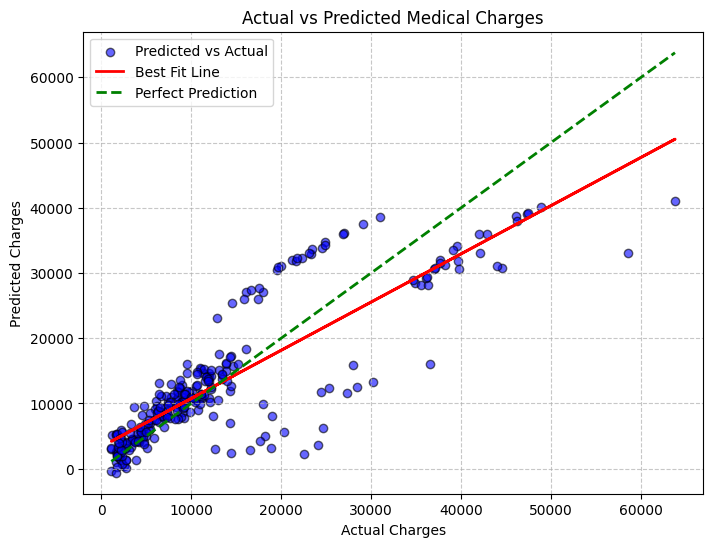

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(Y_test, y_pred, color="blue", alpha=0.6, edgecolor="k", label="Predicted vs Actual")

# Add best-fit line
z = np.polyfit(Y_test, y_pred, 1)   # Linear fit (degree 1 polynomial)
p = np.poly1d(z)
plt.plot(Y_test, p(Y_test), color="red", linewidth=2, label="Best Fit Line")

# Add y=x reference line (perfect prediction)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color="green", linestyle="--", linewidth=2, label="Perfect Prediction")

# Labels and title
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Charges")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


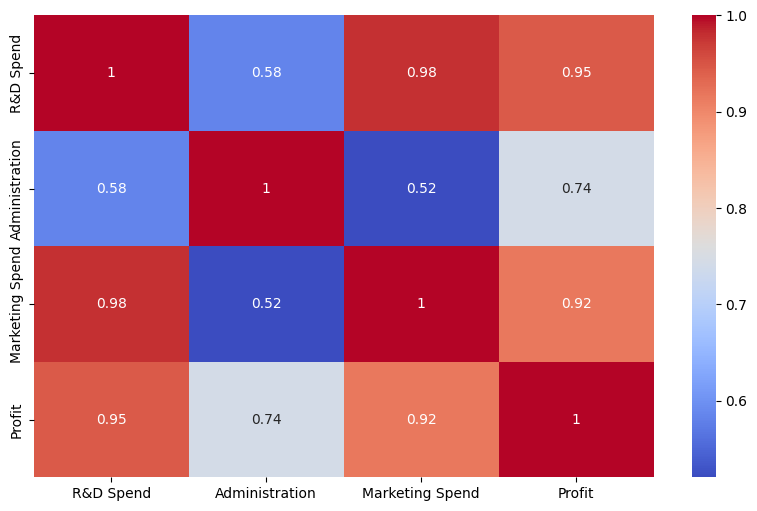

[ 89624.88499984  88261.44060358  94728.57723845 176034.49990954
  83234.84214495]
Predicted: [ 89624.88499984  88261.44060358  94728.57723845 176034.49990954
  83234.84214495]
Actual: [ 89012.02672  87654.55773  94093.35179 175396.2616   83356.61784]
R squared value: 0.91
Mean squared error: 192169702.50


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

companies = pd.read_csv("1000_Companies.csv")
print(companies.head())

# Select only numeric columns
numeric_df = companies.select_dtypes(include=['number'])

# Compute correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Features (all columns except last one)
X = companies.iloc[:, :-1].values

# Target (last column = Profit)
y = companies.iloc[:, -1].values

# Encode categorical column (State at index 3)
labelencoder = LabelEncoder()
X[:, 3] = labelencoder.fit_transform(X[:, 3])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Fit linear regression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Check first few predictions
print(regressor.predict(X_test[:5]))

# Predicting the Test set results
y_pred = regressor.predict(X_test)
print("Predicted:",y_pred[:5])
print("Actual:",y_test[:5])


# Calculating the R squared value, # The mean squared error
print("R squared value: %.2f" %r2_score(y_test,y_pred))
print("Mean squared error: %.2f" %mean_squared_error(y_test,y_pred))